In [3]:
# importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset 

# creating database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,Item ID,Item Name,Category,VendorName,Supplier,AvgPurchasePrice,NetPurchasePrice,TotalSalesQuantity,TotalSalesAmount,TotalNetRevenue,TotalGrossProfit,TotalPurchaseQuantity,TotalPurchaseAmount,TotalAmountPaid,TotalBalanceDue,TotalBalanceDuePercent,StockTurnover,SalestoPurchaseRatio
0,ITM-0051,Material Z-51,Category H,Zeta Imports,Theta Co,175.79,195.53,702,1068176.00,928268.58,-342619.40,1848,1410795.40,1509471.46,0.00,-32.075182,0.379870,0.757145
1,ITM-0089,Part L-89,Category H,Eta Distributors,Zeta Imports,221.95,228.99,746,970470.46,853728.42,241235.17,2604,729235.29,757608.60,51698.99,24.857549,0.286482,1.330806
2,ITM-0011,Component L-11,Category G,Theta Co,Eta Distributors,678.71,828.30,916,918484.44,768290.52,-319291.24,1624,1237775.68,723172.16,586603.84,-34.762836,0.564039,0.742044
3,ITM-0005,Equipment F-5,Category E,Gamma Corp,Delta Wholesale,897.21,967.77,650,881791.54,716681.86,658582.04,675,223209.50,128752.80,73183.75,74.686818,0.962963,3.950511
4,ITM-0024,Part Y-24,Category H,Epsilon Goods,Alpha Supplies,808.88,925.93,705,827836.71,793295.46,376836.21,966,451000.50,411576.18,72602.34,45.520597,0.729814,1.835556


In [3]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AvgPurchasePrice,258.0,543.285271,289.038189,4.510000e+00,266.997500,540.805000,811.500000,1.010250e+03
NetPurchasePrice,258.0,561.093411,310.788971,4.250000e+00,264.530000,560.990000,852.285000,1.181730e+03
TotalSalesQuantity,258.0,279.496124,176.796246,2.500000e+01,163.000000,239.000000,363.000000,9.160000e+02
TotalSalesAmount,258.0,286686.874806,197913.821762,1.164392e+04,119075.120000,263828.410000,381535.650000,1.068176e+06
TotalNetRevenue,258.0,250021.315349,174184.532025,1.024583e+04,104665.270000,221959.920000,332843.600000,9.282686e+05
TotalGrossProfit,258.0,-3252.518798,273615.168706,-1.231733e+06,-132937.162500,34177.485000,168395.967500,6.585820e+05
TotalPurchaseQuantity,258.0,554.321705,491.750404,5.000000e+00,201.250000,393.000000,782.750000,2.888000e+03
TotalPurchaseAmount,258.0,289939.393605,313242.987001,1.287120e+03,66009.285000,180389.850000,349197.412500,1.639779e+06
TotalAmountPaid,258.0,170800.916512,263663.226083,0.000000e+00,0.000000,72087.985000,213734.600000,1.509471e+06
TotalBalanceDue,258.0,136278.404729,230560.096315,0.000000e+00,0.000000,39966.270000,180138.487500,1.781308e+06


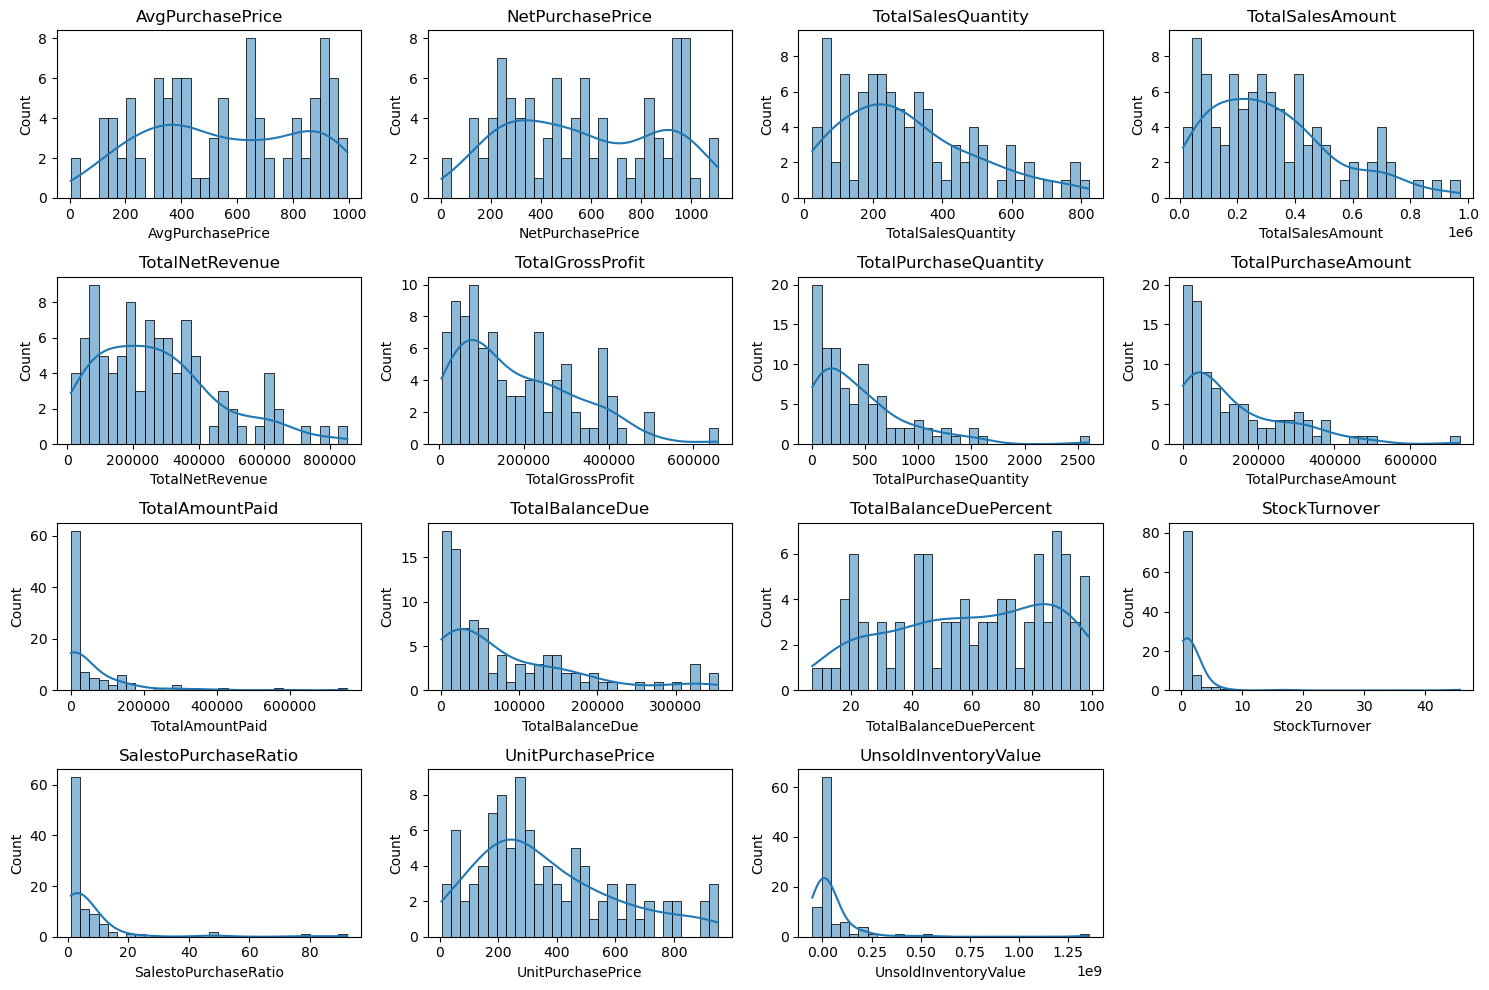

In [187]:
# Distribution PLots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
# plt.show()

plt.savefig("histogram.png", dpi=300, bbox_inches="tight")
plt.show()

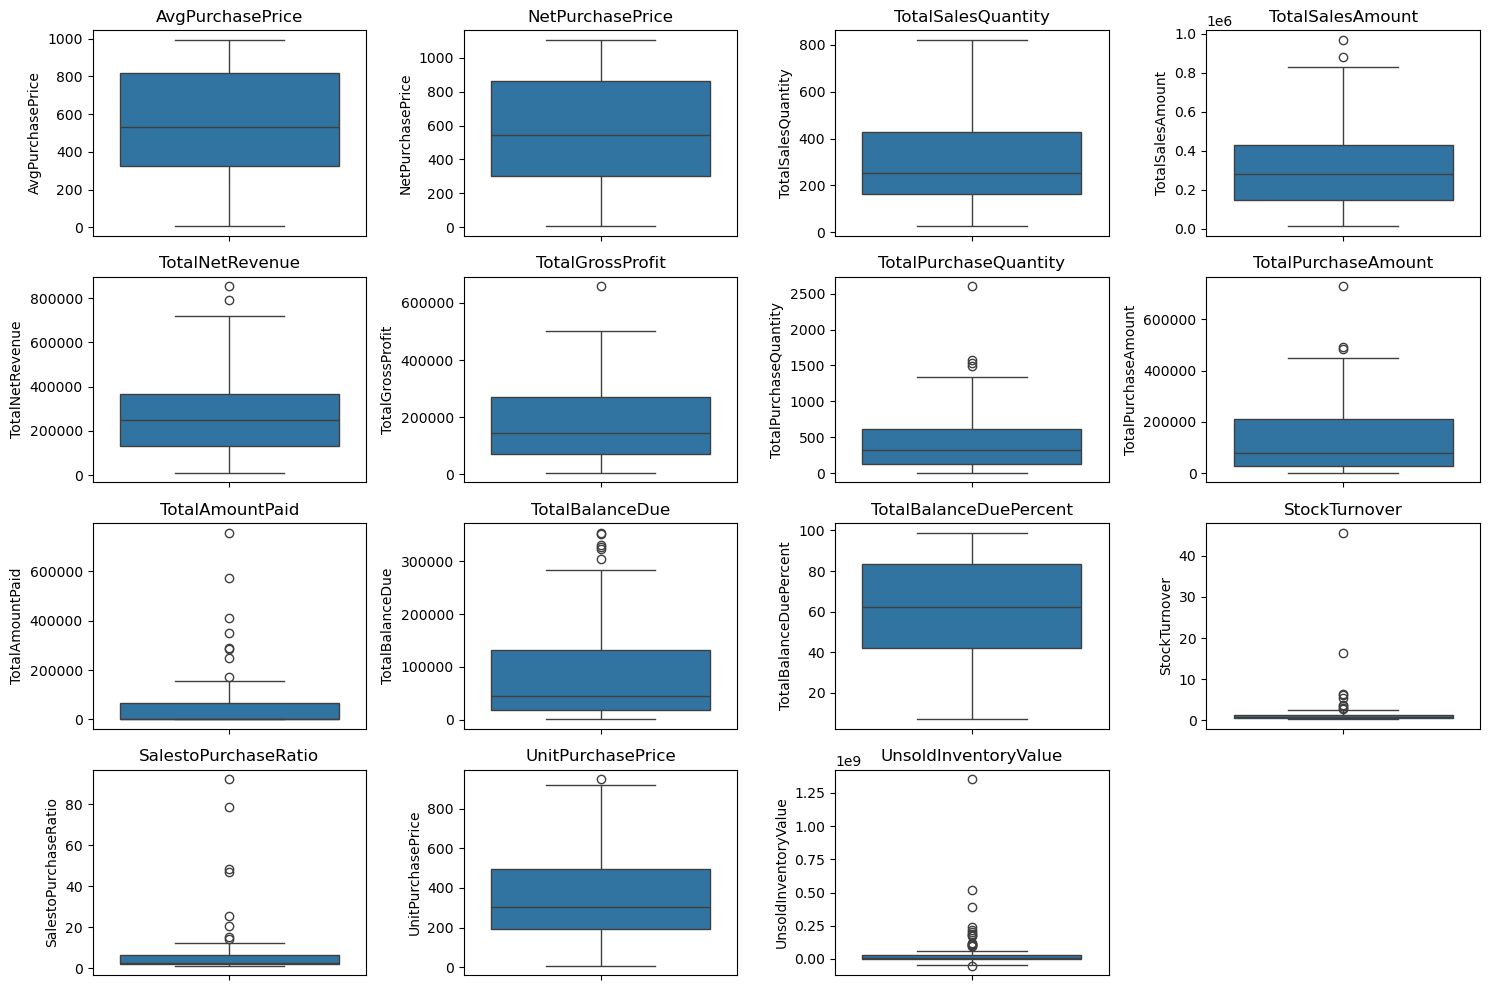

In [189]:
# OutLier Detection with Boxplots

plt.figure(figsize=(15, 10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# let's filter the data by removing inconsistencies

df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE TotalGrossProfit	> 0
AND TotalBalanceDue > 0
AND TotalSalesQuantity > 0""", conn)

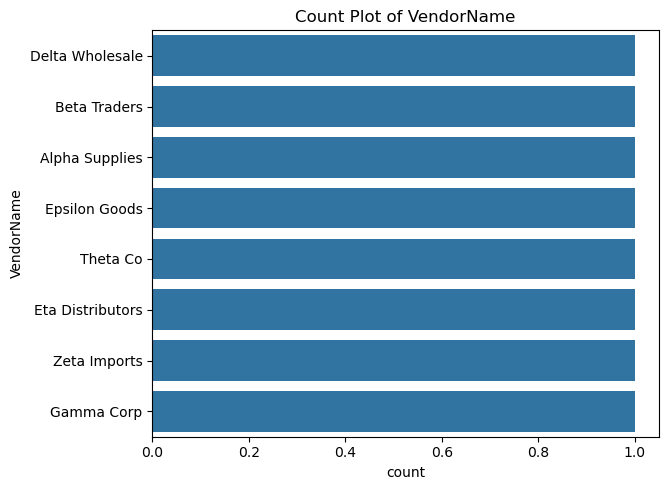

In [190]:
# Distribution PLots for Numerical Columns
numerical_cols = ["VendorName"]

plt.figure(figsize=(12, 5))
for i,col in enumerate(numerical_cols):
    plt.subplot(1, 2, i+1) # Adjust grid layout as needed
    sns.countplot(y=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.savefig("countplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [108]:
# Correlation Heatmap

print(df[numerical_cols].dtypes)

VendorName    object
dtype: object


In [111]:
print(numerical_cols)

['VendorName']


In [112]:
numerical_cols = [
    'AvgPurchasePrice',
    'NetPurchasePrice',
    'TotalSalesQuantity',
    'TotalSalesAmount',
    'TotalNetRevenue',
    'TotalGrossProfit',
    'TotalPurchaseQuantity',
    'TotalPurchaseAmount',
    'TotalAmountPaid',
    'TotalBalanceDue',
    'StockTurnover',
    'SalestoPurchaseRatio'
]

In [113]:
print(numerical_cols)


['AvgPurchasePrice', 'NetPurchasePrice', 'TotalSalesQuantity', 'TotalSalesAmount', 'TotalNetRevenue', 'TotalGrossProfit', 'TotalPurchaseQuantity', 'TotalPurchaseAmount', 'TotalAmountPaid', 'TotalBalanceDue', 'StockTurnover', 'SalestoPurchaseRatio']


In [114]:
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

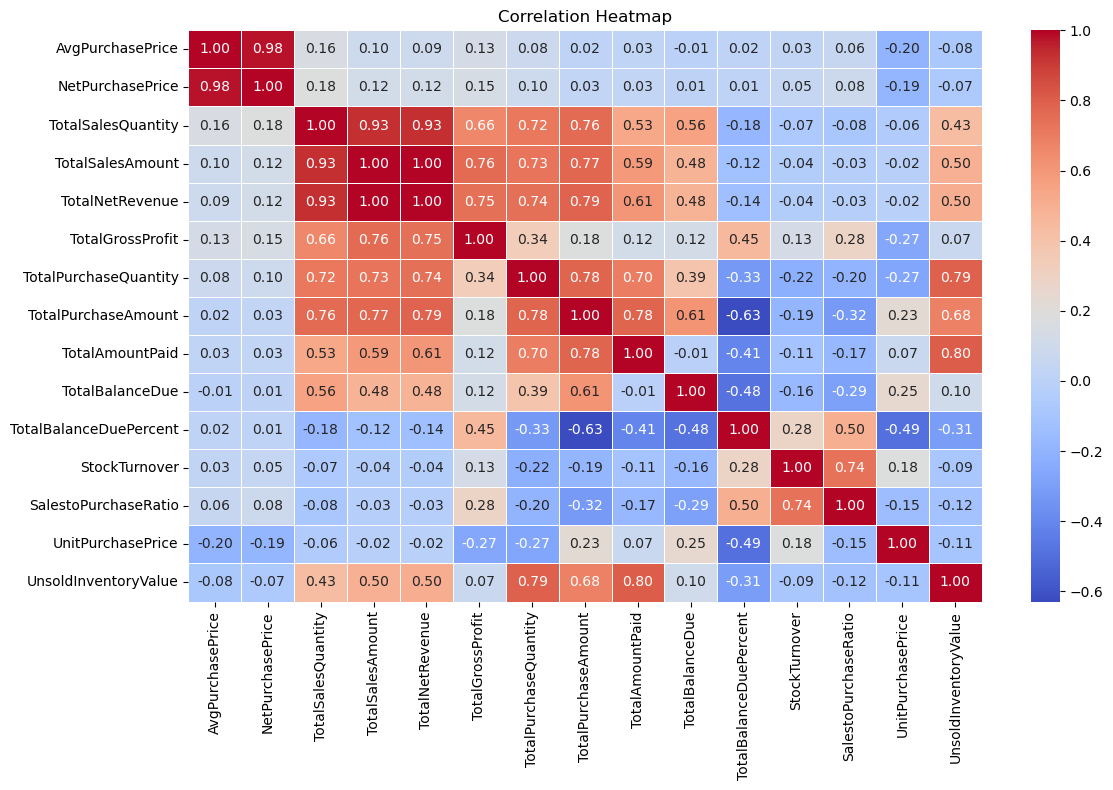

In [195]:
import numpy as np

numerical_cols = df.select_dtypes(include=[np.number]).columns

correlation_matrix = df[numerical_cols].astype(float).corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [107]:
brand_performance = df.groupby('VendorName').agg({
    'TotalSalesAmount': 'sum',
    'TotalBalanceDue': 'mean'
}).reset_index()

In [98]:
low_sales_threshold = brand_performance['TotalSalesAmount'].quantile(0.25)
high_margin_threshold = brand_performance['TotalBalanceDue'].quantile(0.75)

In [99]:
low_sales_threshold

np.float64(2639295.7474999996)

In [100]:
high_margin_threshold

np.float64(110078.98675595238)

In [101]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesAmount'] <= low_sales_threshold) &
    (brand_performance['TotalBalanceDue'] >= high_margin_threshold)
]
print("Brands with low Sales but High Total Balance Due:")
display(target_brands.sort_values('TotalSalesAmount'))

Brands with low Sales but High Total Balance Due:


,VendorName,TotalSalesAmount,TotalBalanceDue
5,Gamma Corp,1156100.84,136357.484


In [102]:
print(brand_performance.shape)
print(target_brands.shape)

display(target_brands)

(8, 3)
(1, 3)


,VendorName,TotalSalesAmount,TotalBalanceDue
5,Gamma Corp,1156100.84,136357.484


In [104]:
brand_performance = brand_performance[brand_performance['TotalSalesAmount']<10000] # for better visualization

In [103]:
print(target_brands)


   VendorName  TotalSalesAmount  TotalBalanceDue
5  Gamma Corp        1156100.84       136357.484


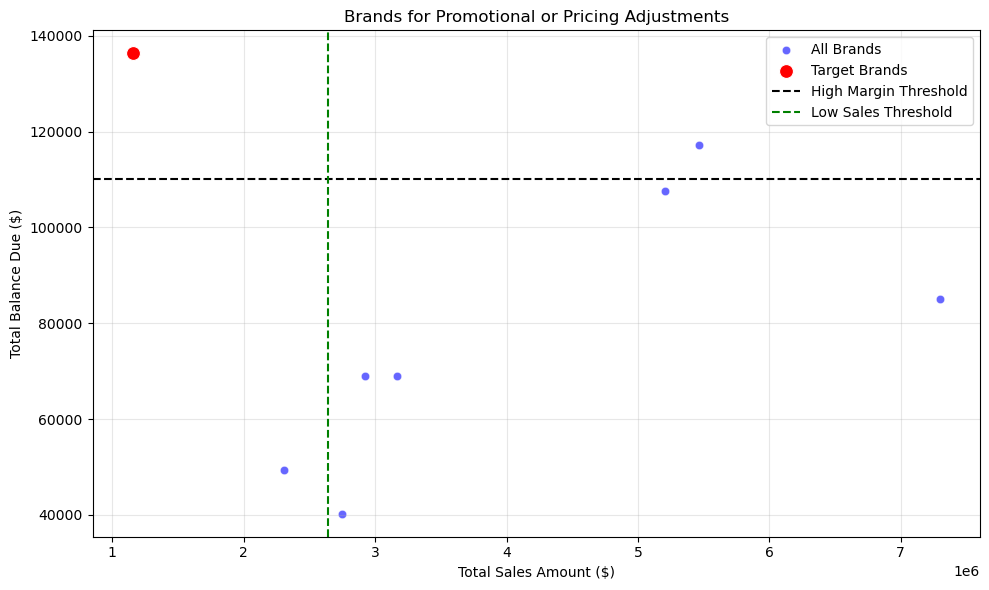

In [196]:
plt.figure(figsize=(10, 6))

# Scatter plot for all brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesAmount',
    y='TotalBalanceDue',
    color='blue',
    label='All Brands',
    alpha=0.6
)

# Highlight target brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesAmount',
    y='TotalBalanceDue',
    color='red',
    s=100,
    label='Target Brands'
)

# Threshold lines
plt.axhline(
    y=high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    x=low_sales_threshold,
    linestyle='--',
    color='green',
    label='Low Sales Threshold'
)

# Labels
plt.xlabel("Total Sales Amount ($)")
plt.ylabel("Total Balance Due ($)")
plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scatterplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [91]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"${value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"${value/1_000:.2f}K"
    else:
        return f"${value:.2f}"

In [92]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesAmount"].sum().nlargest(10)
top_brands = df.groupby("VendorName")["TotalBalanceDue"].sum().nlargest(10)
top_vendors



VendorName
Delta Wholesale     7296714.83
Theta Co            5468626.91
Beta Traders        5208347.21
Alpha Supplies      3167955.59
Epsilon Goods       2923815.53
Zeta Imports        2750693.76
Eta Distributors    2305101.71
Gamma Corp          1156100.84
Name: TotalSalesAmount, dtype: float64

In [93]:
top_brands

VendorName
Delta Wholesale     1955100.91
Beta Traders        1507949.16
Theta Co            1406207.81
Alpha Supplies       897279.76
Epsilon Goods        896621.04
Gamma Corp           681787.42
Eta Distributors     494594.29
Zeta Imports         241490.35
Name: TotalBalanceDue, dtype: float64

In [94]:
top_brands.apply(lambda x : format_dollars(x))

VendorName
Delta Wholesale       $1.96M
Beta Traders          $1.51M
Theta Co              $1.41M
Alpha Supplies      $897.28K
Epsilon Goods       $896.62K
Gamma Corp          $681.79K
Eta Distributors    $494.59K
Zeta Imports        $241.49K
Name: TotalBalanceDue, dtype: object

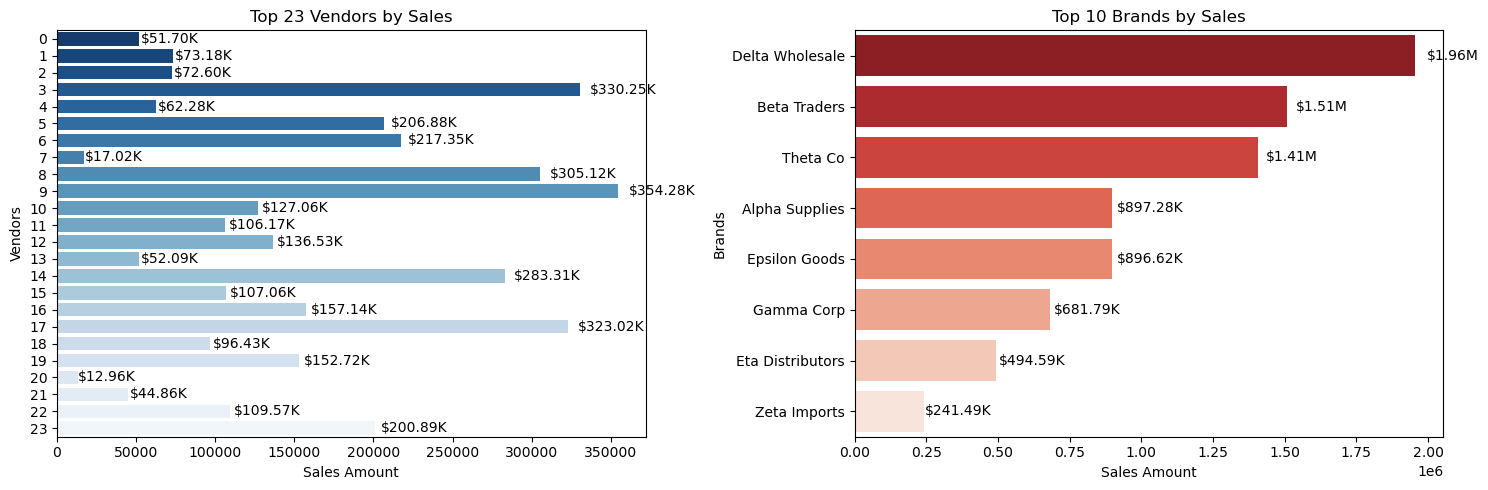

In [199]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index.astype(str),
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 23 Vendors by Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Vendors")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Brands")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.savefig("barplots.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
VendorName,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AvgPurchasePrice,96.0,551.888854,280.462680,4.510000,324.660000,533.460000,817.415000,994.850000
NetPurchasePrice,96.0,569.539062,301.775888,4.250000,303.722500,541.710000,863.767500,1107.520000
TotalSalesQuantity,96.0,298.770833,194.980565,25.000000,161.750000,254.000000,426.000000,822.000000
TotalSalesAmount,96.0,315389.128958,214023.363010,11643.920000,147555.067500,279810.810000,428798.517500,970470.460000
TotalNetRevenue,96.0,275265.010417,187206.118353,10245.830000,130465.005000,246879.710000,365783.620000,853728.420000
TotalGrossProfit,96.0,180999.062708,138373.265942,5266.090000,70239.645000,146257.780000,271853.662500,658582.040000
TotalPurchaseQuantity,96.0,448.833333,446.851669,5.000000,125.750000,326.000000,617.750000,2604.000000
TotalPurchaseAmount,96.0,134390.066250,140372.333345,1287.120000,29995.715000,78152.950000,210419.550000,729235.290000
TotalAmountPaid,96.0,57821.245938,120681.115997,0.000000,0.000000,2289.640000,67037.487500,757608.600000


In [38]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseAmount':'sum',
    'TotalGrossProfit':'sum',
    'TotalSalesAmount':'sum'
}).reset_index()
vendor_performance.shape

(0, 4)

In [42]:
vendor_performance['TotalPurchaseQuantity%'] = vendor_performance['TotalPurchaseAmount']/  vendor_performance['TotalPurchaseAmount'].sum()

In [43]:
round(vendor_performance.sort_values('TotalPurchaseQuantity%', ascending = False),2)

,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount,TotalPurchaseQuantity%


In [45]:
top_vendors = vendor_performance.sort_values('TotalPurchaseQuantity%',
                                             ascending=False
                                            ).head(10)

In [46]:
top_vendors['TotalPurchaseQuantity%'].sum()

np.float64(0.0)

In [51]:
top_vendors['Cumulative_Contribution'] = top_vendors['TotalPurchaseQuantity%'].cumsum()
top_vendors

,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount,TotalPurchaseQuantity%,Cumulative_Contribution,Cumulative_Contribution%


In [54]:
top_vendors


,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount,TotalPurchaseQuantity%,Cumulative_Contribution%


NameError: name 'top_vendors' is not defined

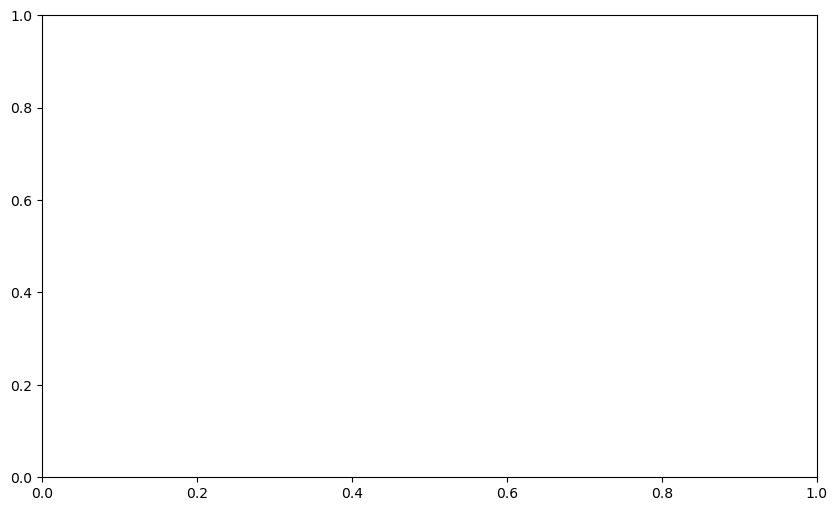

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar Plot
sns.barplot(
    data=top_vendors,
    x='VendorName',
    y='TotalPurchaseQuantity%',
    palette='mako',
    ax=ax1
)

# Values on bars
for i, value in enumerate(top_vendors['TotalPurchaseQuantity%']):
    ax1.text(
        i,
        value,
        f"{value:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

# Line Plot
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# Labels
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Total Purchase Quantity %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# 100% line
ax2.axhline(100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()

# Save BEFORE show
fig.savefig("pareto_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [208]:
print(type(top_vendors))

<class 'pandas.core.series.Series'>


In [72]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseAmount', 'TotalGrossProfit', 'TotalSalesAmount', 'TotalPurchaseQuantity%', 'Cumulative_Contribution%']


In [73]:
print(top_vendors.shape)
print(top_vendors.head())


(0, 6)
Empty DataFrame
Columns: [VendorName, TotalPurchaseAmount, TotalGrossProfit, TotalSalesAmount, TotalPurchaseQuantity%, Cumulative_Contribution%]
Index: []


In [74]:
print(vendor_performance.shape)
vendor_performance.head()

(0, 5)


,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount,TotalPurchaseQuantity%


In [75]:
top_vendors

,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount,TotalPurchaseQuantity%,Cumulative_Contribution%


In [76]:
print(df.shape)

(96, 18)


In [77]:
print(df.columns.tolist())

['Item ID', 'Item Name', 'Category', 'VendorName', 'Supplier', 'AvgPurchasePrice', 'NetPurchasePrice', 'TotalSalesQuantity', 'TotalSalesAmount', 'TotalNetRevenue', 'TotalGrossProfit', 'TotalPurchaseQuantity', 'TotalPurchaseAmount', 'TotalAmountPaid', 'TotalBalanceDue', 'TotalBalanceDuePercent', 'StockTurnover', 'SalestoPurchaseRatio']


In [78]:
df['VendorName'].isna().sum()

np.int64(96)

In [79]:
df[['VendorName']].head()

,VendorName
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [80]:
print(df[['Supplier', 'VendorName']].head(10))

          Supplier  VendorName
0     Zeta Imports         NaN
1  Delta Wholesale         NaN
2   Alpha Supplies         NaN
3         Theta Co         NaN
4     Beta Traders         NaN
5    Epsilon Goods         NaN
6         Theta Co         NaN
7         Theta Co         NaN
8  Delta Wholesale         NaN
9         Theta Co         NaN


In [81]:
df['VendorName'] = df['Supplier']

In [82]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseAmount': 'sum',
    'TotalGrossProfit': 'sum',
    'TotalSalesAmount': 'sum'
}).reset_index()

print(vendor_performance.shape)

(8, 4)


In [83]:
vendor_performance.head()

,VendorName,TotalPurchaseAmount,TotalGrossProfit,TotalSalesAmount
0,Alpha Supplies,1630474.42,1537481.17,3167955.59
1,Beta Traders,2181474.50,3026872.71,5208347.21
2,Delta Wholesale,2279821.73,5016893.10,7296714.83
3,Epsilon Goods,1384809.69,1539005.84,2923815.53
4,Eta Distributors,687779.37,1617322.34,2305101.71


In [84]:
vendor_performance['TotalPurchaseQuantity%'] = (
    vendor_performance['TotalPurchaseAmount']
    / vendor_performance['TotalPurchaseAmount'].sum()
) * 100

In [85]:
top_vendors = vendor_performance.sort_values(
    'TotalPurchaseQuantity%',
    ascending=False
)

In [86]:
top_vendors['Cumulative_Contribution%'] = (
    top_vendors['TotalPurchaseQuantity%'].cumsum()
)

In [87]:
print(top_vendors.head())

        VendorName  TotalPurchaseAmount  TotalGrossProfit  TotalSalesAmount  \
6         Theta Co           2633596.70        2835030.21        5468626.91   
2  Delta Wholesale           2279821.73        5016893.10        7296714.83   
1     Beta Traders           2181474.50        3026872.71        5208347.21   
0   Alpha Supplies           1630474.42        1537481.17        3167955.59   
7     Zeta Imports           1415609.25        1335084.51        2750693.76   

   TotalPurchaseQuantity%  Cumulative_Contribution%  
6               20.413190                 20.413190  
2               17.671055                 38.084245  
1               16.908759                 54.993004  
0               12.637920                 67.630924  
7               10.972485                 78.603409  


In [119]:
print(top_vendors.shape)

(8,)


In [120]:
top_vendors.head()

VendorName
Delta Wholesale    7296714.83
Theta Co           5468626.91
Beta Traders       5208347.21
Alpha Supplies     3167955.59
Epsilon Goods      2923815.53
Name: TotalSalesAmount, dtype: float64

In [127]:
top_vendors.columns

Index(['VendorName', 'TotalPurchaseAmount', 'TotalGrossProfit',
       'TotalSalesAmount', 'TotalPurchaseQuantity%'],
      dtype='object')

In [124]:
top_vendors = vendor_performance.sort_values(
    by='TotalPurchaseQuantity%',
    ascending=False
).head(10)

In [125]:
print(type(top_vendors))

<class 'pandas.core.frame.DataFrame'>


In [126]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseAmount', 'TotalGrossProfit', 'TotalSalesAmount', 'TotalPurchaseQuantity%']


In [128]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['TotalPurchaseQuantity%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 100.0 %


In [1]:
vendors = list(top_vendors['VendorName'].values)

TotalPurchaseQuantity = list(top_vendors['TotalPurchaseQuantity%'].values)

total_contribution = sum(TotalPurchaseQuantity)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
TotalPurchaseQuantity.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    TotalPurchaseQuantity,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the centre
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Add Total Contribution Annotation in the center
ax.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top Vendors Purchase Contribution (%)")

plt.tight_layout()
plt.savefig("donut_chart.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'top_vendors' is not defined

In [133]:
df['UnitPurchasePrice'] = df['TotalPurchaseAmount'] / df['TotalPurchaseQuantity']

In [135]:
df

,Item ID,Item Name,Category,VendorName,Supplier,AvgPurchasePrice,NetPurchasePrice,TotalSalesQuantity,TotalSalesAmount,TotalNetRevenue,TotalGrossProfit,TotalPurchaseQuantity,TotalPurchaseAmount,TotalAmountPaid,TotalBalanceDue,TotalBalanceDuePercent,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,ITM-0089,Part L-89,Category H,Zeta Imports,Zeta Imports,221.95,228.99,746,970470.46,853728.42,241235.17,2604,729235.29,757608.60,51698.99,24.857549,0.286482,1.330806,280.044274
1,ITM-0005,Equipment F-5,Category E,Delta Wholesale,Delta Wholesale,897.21,967.77,650,881791.54,716681.86,658582.04,675,223209.50,128752.80,73183.75,74.686818,0.962963,3.950511,330.680741
2,ITM-0024,Part Y-24,Category H,Alpha Supplies,Alpha Supplies,808.88,925.93,705,827836.71,793295.46,376836.21,966,451000.50,411576.18,72602.34,45.520597,0.729814,1.835556,466.874224
3,ITM-0100,Product W-100,Category F,Theta Co,Theta Co,544.27,509.42,651,729830.73,604333.20,388948.50,981,340882.23,20506.98,330253.02,53.292974,0.663609,2.141006,347.484434
4,ITM-0027,Supply B-27,Category G,Beta Traders,Beta Traders,650.52,662.15,592,727458.19,641211.40,501024.99,1340,226433.20,171907.00,62281.50,68.873373,0.441791,3.212683,168.980000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,ITM-0015,Tool P-15,Category F,Delta Wholesale,Delta Wholesale,632.96,630.12,125,60276.91,51881.41,26730.13,171,33546.78,0.00,37486.50,44.345555,0.730994,1.796802,196.180000
92,ITM-0092,Widget O-92,Category B,Delta Wholesale,Delta Wholesale,431.42,454.86,25,41434.75,34888.06,33987.52,21,7447.23,0.00,8172.59,82.026608,1.190476,5.563780,354.630000
93,ITM-0092,Widget O-92,Category B,Delta Wholesale,Delta Wholesale,431.42,454.86,25,41434.75,34888.06,34902.22,41,6532.53,0.00,7809.77,84.234175,0.609756,6.342833,159.330000
94,ITM-0092,Widget O-92,Category B,Delta Wholesale,Delta Wholesale,431.42,454.86,25,41434.75,34888.06,27539.29,17,13895.46,0.00,15724.39,66.464236,1.470588,2.981891,817.380000


In [136]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [137]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,2604
1,Large,675
2,Large,966
3,Large,981
4,Large,1340
...,...,...
91,Small,171
92,Small,21
93,Small,41
94,Small,17


In [138]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,425.618862
Medium,389.990130
Large,270.932122


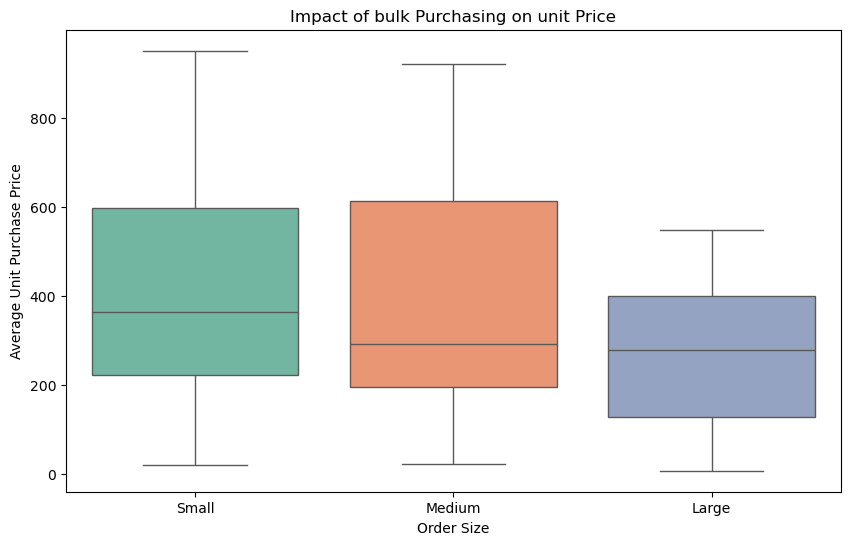

In [140]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of bulk Purchasing on unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

In [144]:
# which vendors have low inventory turnover, indicating excess stock and slow-moving products?

df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
Zeta Imports,0.378711
Gamma Corp,0.447075
Theta Co,0.576241
Epsilon Goods,0.587927
Eta Distributors,0.610410
Alpha Supplies,0.622870
Delta Wholesale,0.633769
Beta Traders,0.649994


In [155]:
def format_Amount(amount):
    return f"₹{amount:,.2f}"

In [156]:
#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

df["UnsoldInventoryValue"]= (df["TotalPurchaseQuantity"]- df["TotalSalesQuantity"]) * df["TotalPurchaseAmount"]
print('Total Unsold Capital:', format_Amount(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: ₹4,604,178,117.76


In [157]:
# Aggregate Capital locked per vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with the highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_Amount)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
7,Zeta Imports,"₹1,890,180,099.56"
6,Theta Co,"₹825,177,174.48"
2,Delta Wholesale,"₹560,121,902.04"
1,Beta Traders,"₹315,441,562.86"
3,Epsilon Goods,"₹310,391,327.84"
0,Alpha Supplies,"₹290,978,178.72"
5,Gamma Corp,"₹236,786,853.18"
4,Eta Distributors,"₹175,101,019.08"


In [159]:
top_threshold = df["TotalSalesAmount"].quantile(0.75)
low_threshold = df["TotalSalesAmount"].quantile(0.25)

In [162]:
top_vendors = df[df["TotalSalesAmount"] >= top_threshold]["TotalBalanceDue"].dropna()
low_vendors = df[df["TotalSalesAmount"] <= top_threshold]["TotalBalanceDue"].dropna()

In [163]:
top_vendors

0      51698.99
1      73183.75
2      72602.34
3     330253.02
4      62281.50
5     206880.56
6     217349.44
7      17019.92
8     305124.66
9     354276.72
10    127058.22
11    106173.60
12    136532.97
13     52085.36
14    283310.72
15    107057.02
16    157139.01
17    323017.83
18     96429.24
19    152718.80
20     12961.12
21     44857.95
22    109574.25
23    200888.00
Name: TotalBalanceDue, dtype: float64

In [164]:
low_vendors

24    351063.65
25    139420.08
26      6200.16
27     56169.06
28     49296.24
        ...    
91     37486.50
92      8172.59
93      7809.77
94     15724.39
95       897.54
Name: TotalBalanceDue, Length: 72, dtype: float64

In [165]:
def confidence_interval(data, confidence=0.95):
    mean_val - np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) #Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [166]:
vendor_performance["ProfitMargin"] = (
    vendor_performance["TotalGrossProfit"] /
    vendor_performance["TotalSalesAmount"]
) * 100

Top Vendors 95% CI: (46.30, 63.47), Mean: 54.89
Low Vendors 95% CI: (46.30, 63.47) , Mean: 54.89


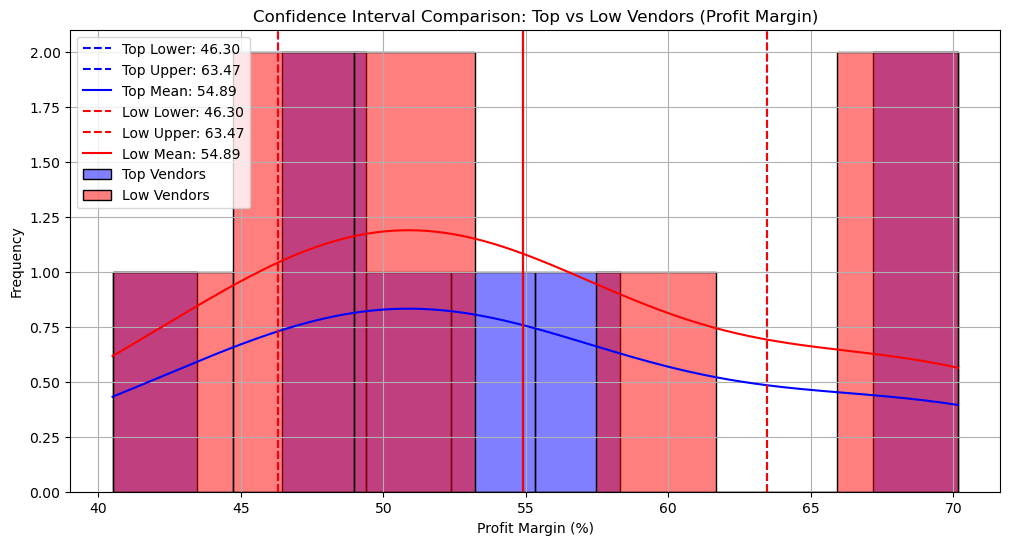

In [169]:
from scipy import stats
import numpy as np

# Top & Low Vendors based on Profit Margin
top_vendors = vendor_performance.nlargest(10, "ProfitMargin")["ProfitMargin"]
low_vendors = vendor_performance.nsmallest(10, "ProfitMargin")["ProfitMargin"]


# Function to calculate 95% Confidence Interval
def confidence_interval(data):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + 0.95) / 2, len(data) - 1)
    lower = mean - margin
    upper = mean + margin
    return mean, lower, upper


# Confidence Intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}) , Mean: {low_mean:.2f}")


plt.figure(figsize=(12,6))

# Top Vendors
sns.histplot(top_vendors, kde=True, color="blue", bins=10,
             alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--",
            label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--",
            label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-",
            label=f"Top Mean: {top_mean:.2f}")

# Low Vendors
sns.histplot(low_vendors, kde=True, color="red", bins=7,
             alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--",
            label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--",
            label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-",
            label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [171]:
from scipy.stats import ttest_ind

# Calculate thresholds
top_threshold = df["TotalSalesAmount"].quantile(0.75)
low_threshold = df["TotalSalesAmount"].quantile(0.25)

# Separate top and low-performing vendors
top_vendors = df[df["TotalSalesAmount"] >= top_threshold]["TotalBalanceDue"].dropna()
low_vendors = df[df["TotalSalesAmount"] <= low_threshold]["TotalBalanceDue"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: There is a significant difference in Total Balance Due between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in Total Balance Due between top and low-performing vendors.")

T-Statistic: 5.9991
P-Value: 0.0000
Reject H0: There is a significant difference in Total Balance Due between top and low-performing vendors.


In [180]:
brand_performance.to_csv("BrandPerformance.csv", index=False)
low_vendors.to_csv("LowTurnoverVendor.csv", index=False)
top_vendors.to_csv("PurchaseContribution.csv", index=False)
#vendor_sales_summary.to_csv("vendor_sales_summary.csv", index=False)

In [178]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'warnings', 'sqlite3', 'ttest_ind', 'stats', '_i2', 'conn', 'df', '_2', '_i3', '_3', '_i4', 'numerical_cols', 'i', 'col', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', 'correlation_matrix', '_i11', 'brand_performance', '_i12', 'low_sales_threshold', 'high_margin_threshold', '_i13', '_13', '_i14', '_14', '_i15', '_i16', '_i17', '_i18', 'target_brands', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', 'top_vendors', 'top_brands', '_27', '_i28', '_28', '_i29', 'format_dollars', '_i30', '_30', '_i31', 'ax1', '__annotations__', 'ax2', '_i32', '_32', '_i33', '_33', '_i34', 'vendor_performance', '_i35', '_i36', '_36', '_i37', '_37', '_i38', '_38', '_i39', '_i40', '_i41', '_i42', '_i43', '_43', '_i44', '_i45', '_

In [181]:
for name in globals():
    if "vendor" in name.lower():
        print(name)

RuntimeError: dictionary changed size during iteration

In [182]:
for name in globals():
    if "summary" in name.lower():
        print(name)

In [183]:
df.to_csv("vendor_sales_summary.csv",index=False)